<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Objective" data-toc-modified-id="Objective-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Objective</a></span></li><li><span><a href="#Algorithm-Steps" data-toc-modified-id="Algorithm-Steps-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Algorithm Steps</a></span></li><li><span><a href="#Notes" data-toc-modified-id="Notes-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Notes</a></span></li><li><span><a href="#The-standard-RLS-algorithm" data-toc-modified-id="The-standard-RLS-algorithm-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>The standard RLS algorithm</a></span><ul class="toc-item"><li><span><a href="#Example-of-aplication:-system-identification" data-toc-modified-id="Example-of-aplication:-system-identification-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Example of aplication: system identification</a></span></li><li><span><a href="#Example-of-aplication:-channel-equalization" data-toc-modified-id="Example-of-aplication:-channel-equalization-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Example of aplication: channel equalization</a></span></li></ul></li><li><span><a href="#Time-varying-systems" data-toc-modified-id="Time-varying-systems-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Time-varying systems</a></span></li></ul></div>

In [1]:
if 'google.colab' in str(get_ipython()):    
    ! git clone -b master https://github.com/edsonportosilva/adaptive-signal-processing
    from os import chdir as cd
    cd('/content/notebooks/')
    ! pip install -e .
    ! pip install SciencePlots

import sympy as sp
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from IPython.core.display import HTML
from IPython.display import Image
try:
    import scienceplots
except:
    ! pip install SciencePlots
    
from utils import set_preferences, genConvGIF, symdisp, round_expr

plt.style.use(['science','ieee'])
set_preferences()

plt.rcParams['figure.figsize'] = [5, 2.5]
plt.rcParams['figure.dpi'] = 200

saveFigures = False
figurePath = 'G:\\Meu Drive\\DEE UFCG\\Disciplinas e ementas\\TEEE - Processamento adaptativo de sinais\\lecture notes\\figures\\'

In [4]:
from algorithms import estimate_correlation_matrix, estimate_cross_correlation, lms, nlms, lms_newton

# Least Squares 

True coefficients: [10, 5, 0.2, -0.02]
Estimated coefficients (LS): [11.5166132   5.6573323   0.17779912 -0.01897596]
Standard errors of coefficients: [0.65790326 0.48545582 0.01706806 0.00091026]


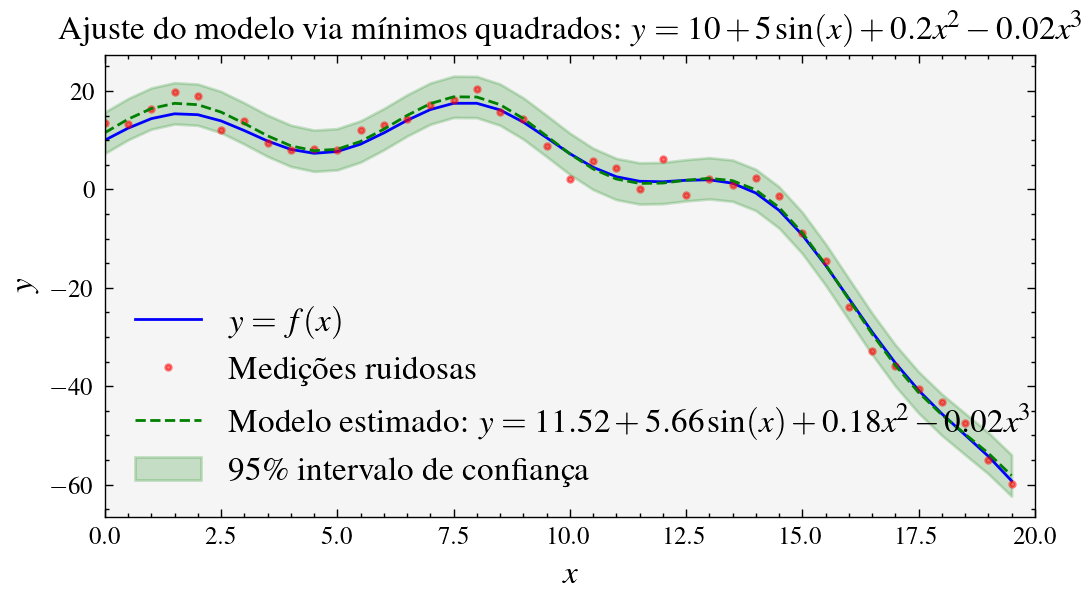

In [5]:
# Perform least squares estimation of a nonlinear model with noisy measurements

np.random.seed(0)

# Input range
x = np.arange(0,20, 0.5)

# Model coefficients
a = 10
b = 5
c = 0.2
d = -0.02 

# True model output
y = a + b*np.sin(x) + c*x**2 + d*x**3

# Measurements with noise
σ = 2
n = np.random.normal(0, σ, size=y.shape)
y_noisy = y + n

# Least squares estimation
X = np.vstack([np.ones_like(x), np.sin(x), x**2, x**3]).T

theta_ls = np.linalg.inv(X.T @ X ) @ X.T @ y_noisy
print("True coefficients:", [a, b, c, d])
print("Estimated coefficients (LS):", theta_ls)

y_ls = X @ theta_ls

# confidence intervals for the coefficients
residuals = y_noisy - y_ls
s2 = np.sum(residuals**2) / (len(y_noisy) - len(theta_ls))
cov_theta = s2 * np.linalg.inv(X.T @ X)
print("Standard errors of coefficients:", np.sqrt(np.diag(cov_theta)))

plt.figure(figsize=(6, 3))
plt.plot(x, y, linewidth=1, label='$y=f(x)$', color='blue')
plt.plot(x, y_noisy, 'o', label='Medições ruidosas', color='red', alpha=0.5)
plt.plot(x, y_ls, linewidth=1, label=f'Modelo estimado: $y = {theta_ls[0]:.2f} + {theta_ls[1]:.2f}\\sin(x) + {theta_ls[2]:.2f}x^2  {theta_ls[3]:.2f}x^3$', color='green')
plt.fill_between(x, y_ls - 2*np.sqrt(s2), y_ls + 2*np.sqrt(s2), color='green', alpha=0.2, label='95\% intervalo de confiança')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title(f'Ajuste do modelo via mínimos quadrados: $y = {a} + {b}\\sin(x) + {c}x^2  {d}x^3$')
plt.xlim(0, 20)
plt.show()


# RLS algorithms

The RLS algorithm is used to find the coefficients of an adaptive filter that minimize the least squares cost function. The algorithm provides a fast way to update these coefficients as new data arrives.

## Objective

The goal is to minimize the following cost function:

$$
J[n] = \sum_{i=0}^{n} \lambda^{n-i} e^2[i]
$$

where:
- $J[n]$ is the cost function at time $n$.
- $\lambda$ is the forgetting factor $(0 < \lambda \leq 1)$.
- $e[i]$ is the estimation error at time $i$, defined as $e[i] = d[i] - \boldsymbol{h}^T[i] \boldsymbol{x}[i]$.
- $d[i]$ is the desired response at time $i$.
- $\boldsymbol{h}[i]$ is the filter coefficient vector.
- $\boldsymbol{x}[i]$ is the input vector.

## Algorithm Steps

1. **Initialization**:
   - Set the filter coefficients to zero: $\boldsymbol{h}[0] = 0$.
   - Initialize the inverse correlation matrix: $\boldsymbol{P}[0] = \delta^{-1} \boldsymbol{I}$, where $\delta$ is a small positive constant, and $\boldsymbol{I}$ is the identity matrix.

2. **Gain Vector Calculation**:
   - Compute the gain vector $\boldsymbol{k}[n]$:
     $$
     \boldsymbol{k}[n] = \frac{\boldsymbol{P}[n-1] \boldsymbol{x}[n]}{\lambda + \boldsymbol{x}^T[n] \boldsymbol{P}[n-1] \boldsymbol{x}[n]}
     $$

3. **Filter Coefficients Update**:
   - Update the filter coefficients $\boldsymbol{h}[n]$:
     $$
     \boldsymbol{h}[n] = \boldsymbol{h}[n-1] + \boldsymbol{k}[n] e[n]
     $$
   - Here, $e[n] = d[n] - \boldsymbol{h}^T[n-1] \boldsymbol{x}[n]$ is the error at time $n$.

4. **Inverse Correlation Matrix Update**:
   - Update the inverse correlation matrix $\boldsymbol{P}[n]$:
     $$
     \boldsymbol{P}[n] = \frac{1}{\lambda} \left[ \boldsymbol{P}[n-1] - \boldsymbol{k}[n] \boldsymbol{x}^T[n] \boldsymbol{P}[n-1] \right]
     $$

## Notes

- The **forgetting factor** $\lambda$ controls the weight given to past data. Values close to 1 give more weight to older data, while values closer to 0 emphasize recent data.
- The **inverse correlation matrix** $\boldsymbol{P}[n]$ plays a crucial role in updating the filter coefficients efficiently.
- The algorithm is well-suited for real-time applications due to its recursive nature.

## The standard RLS algorithm

In [6]:
@njit
def rls(x, d, Ntaps, λ):
    """
    The Recursive Least Squares (RLS) algorithm.

    Parameters:
        x (ndarray): The input signal.
        d (ndarray): The reference signal.
        Ntaps (int): The number of filter taps.
        λ (float): RLS forgetting factor.       

    Returns:
        tuple: A tuple containing:
            - ndarray: The output signal.
            - ndarray: The final filter coefficients.
            - ndarray: The squared error at each iteration.

    """
    # Initialize the equalizer filter coefficients
    h = np.zeros((Ntaps,1), dtype=np.float64) 
    H = np.zeros((len(x)-Ntaps, Ntaps), dtype=np.float64)
    Rxx_inv = 1e-3*np.eye(Ntaps, dtype=np.float64)
    pxd = np.zeros((Ntaps,1), dtype=np.float64)
       
    # Apply the LMS-Newton algorithm
    ind = np.arange(0,Ntaps)
    squaredError = np.zeros(x.shape, dtype=np.float64)
    out = np.zeros(x.shape, dtype=np.float64)    
    x = x.reshape(-1,1).astype(np.float64)
    
    # Iterate through each sample of the signal
    for i in range(Ntaps, x.shape[0]):
        x_vec = x[i-ind,:]   
        
        # Generate the estimated signal using the equalizer filter
        y = np.sum(x_vec * h)
    
        # Compute the a priori error between the estimated signal and the reference signal
        error = d[i] - y 

        # Update inverse correlation matrix      
        Rxx_inv = 1/λ*(Rxx_inv - ( Rxx_inv @ (x_vec@x_vec.T) @ Rxx_inv)/( λ + x_vec.T @ Rxx_inv @ x_vec) )

        # Update inverse correlation matrix      
        pxd = x_vec * d[i] + λ*pxd

        # Update the filter coefficients using the RLS update rule
        h = Rxx_inv @ pxd                 
        
        squaredError[i] = error**2
        out[i] = y
        H[i-Ntaps,:] = h.T

    return out, h, squaredError, H

@njit
def rls_apriori(x, d, Ntaps, λ):
    """
    The Recursive Least Squares (RLS) algorithm with a priori error.

    Parameters:
        x (ndarray): The input signal.
        d (ndarray): The reference signal.
        Ntaps (int): The number of filter taps.
        λ (float): RLS forgetting factor.       

    Returns:
        tuple: A tuple containing:
            - ndarray: The output signal.
            - ndarray: The final filter coefficients.
            - ndarray: The squared error at each iteration.

    """
    # Initialize the equalizer filter coefficients
    h = np.zeros((Ntaps,1), dtype=np.float64) 
    H = np.zeros((len(x)-Ntaps, Ntaps), dtype=np.float64)
    P = 1e-3*np.eye(Ntaps, dtype=np.float64)
           
    # Apply the LMS-Newton algorithm
    ind = np.arange(0,Ntaps)
    squaredError = np.zeros(x.shape, dtype=np.float64)
    out = np.zeros(x.shape, dtype=np.float64)    
    x = x.reshape(-1,1).astype(np.float64)
    
    # Iterate through each sample of the signal
    for i in range(Ntaps, x.shape[0]):
        x_vec = x[i-ind,:]   
        # Calculate the Kalman gain
        g =  (1/λ)* P @ x_vec /( 1 +  (1/λ) * x_vec.T @ P @ x_vec )
        
        # Generate the filter output
        y = np.sum(x_vec * h)
    
        # Compute the a priori error between the estimated signal and the reference signal
        error = d[i] - y 
        
        # Update the filter coefficients using the RLS update rule with error a priori
        h += g*error  

        # Update inverse correlation matrix      
        P = (1/λ)*P - (1/λ)  * g @ x_vec.T @ P                             
        
        squaredError[i] = error**2
        out[i] = y
        H[i-Ntaps,:] = h.T

    return out, h, squaredError, H

@njit
def rls_aposteriori(x, d, Ntaps, λ):
    """
    The Recursive Least Squares (RLS) algorithm with a posteriori error.

    Parameters:
        x (ndarray): The input signal.
        d (ndarray): The reference signal.
        Ntaps (int): The number of filter taps.
        λ (float): RLS forgetting factor.       

    Returns:
        tuple: A tuple containing:
            - ndarray: The output signal.
            - ndarray: The final filter coefficients.
            - ndarray: The squared error at each iteration.

    """
    # Initialize the equalizer filter coefficients
    h = np.zeros((Ntaps,1), dtype=np.float64) 
    H = np.zeros((len(x)-Ntaps, Ntaps), dtype=np.float64)
    P = 1e-3*np.eye(Ntaps, dtype=np.float64)
           
    # Apply the LMS-Newton algorithm
    ind = np.arange(0,Ntaps)
    squaredError = np.zeros(x.shape, dtype=np.float64)
    out = np.zeros(x.shape, dtype=np.float64)    
    x = x.reshape(-1,1).astype(np.float64)
    
    # Iterate through each sample of the signal
    for i in range(Ntaps, x.shape[0]):
        x_vec = x[i-ind,:] 
        
        # Calculate the Kalman gain
        g =  (1/λ)* P @ x_vec
        
        # Generate the filter output
        y = np.sum(x_vec * h)
    
        # Compute the a priori error between the estimated signal and the reference signal
        error = d[i] - y 
        
        # Calculate conversion factor
        α = 1 + g.T @ x_vec
        
        # Update the filter coefficients using the RLS update rule with error a posteriori
        h += g*(error/α)  

        # Update inverse correlation matrix      
        P = (1/λ)*P - (1/λ)  * (g/α) @ x_vec.T @ P                             
        
        squaredError[i] = error**2
        out[i] = y
        H[i-Ntaps,:] = h.T

    return out, h, squaredError, H

### Example of aplication: system identification

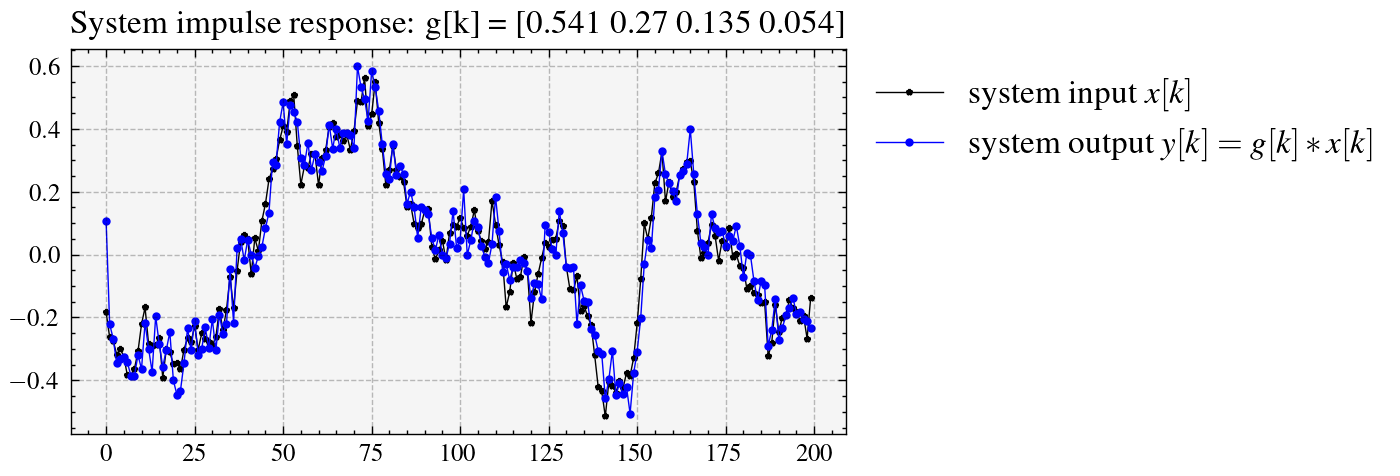

In [7]:
nsamples = 100000
σ2 = 0.0025 # noise variance

# Define input signal to the system
#x = 2*np.random.randint(0, 2, nsamples)-1
x = np.convolve(np.random.normal(0, 0.8, nsamples), np.ones(16)/16,'same')
#x = np.random.normal(0, 1, nsamples)
#x = np.sin(2*np.pi*np.arange(0, nsamples)*0.01)

# Define impulse response of the system
g = np.array([1, 0.5, 0.25, 0.1])
g = g/np.sum(g)

# Convolve input signal with system's impulse response
y = np.convolve(x, g,'same')
y = np.roll(y, 1) # remove input-output delay

# Generate noise and add noise to the systens output
n = np.random.normal(0, np.sqrt(σ2), nsamples)
y += n

plt.plot(x[0:200],'-*k', label='system input $x[k]$')
plt.plot(y[0:200],'-ob', label='system output $y[k] = g[k]\\ast x[k]$');
plt.title(f'System impulse response: g[k] = {g.round(3)}');
plt.legend(bbox_to_anchor=(1, 1));
plt.grid()

In [8]:
# Estimate correlation matrix R = E[x*x.T]
R = estimate_correlation_matrix(x, 4)

symdisp('\\boldsymbol{R}_{xx} = ', sp.Matrix(R), numDig=3)

<IPython.core.display.Math object>

In [9]:
# Calculate eigenvalues and eigenvectors associated to R
eigenvalues, eigenvectors = np.linalg.eig(R)

Λ = sp.Matrix(np.diag(eigenvalues))
Q = sp.Matrix(eigenvectors)

print('Matrix of eigenvalues of R:')
symdisp('\\boldsymbol{Λ} = ', Λ, numDig=3)
#symdisp('\\boldsymbol{Q} = ', Q, numDig=3)
#symdisp('\\boldsymbol{R} = \\boldsymbol{Q}\\boldsymbol{Λ}\\boldsymbol{Q}^T = ', Q*Λ*Q.T, numDig=3)

Matrix of eigenvalues of R:


<IPython.core.display.Math object>

In [10]:
# Estimate cross correlation matrix R = E[d*x]
p = estimate_cross_correlation(x, y, 4)

symdisp('\\boldsymbol{p}_{yx} = ', sp.Matrix(p), numDig=3)

h_opt = np.linalg.inv(R)@p
mmse_sys_id = np.mean(y**2) - (h_opt.T)@p

print('Impulse response of the system:')
symdisp('\\boldsymbol{g} = ', sp.Matrix(g), numDig=3)
print('Estimated impulse response of the system :')
symdisp('\\boldsymbol{h}_{opt} =  \\boldsymbol{R}_{xx}^{-1}\\boldsymbol{p}_{yx} =', sp.Matrix(h_opt), numDig=3)
symdisp('\\mathrm{MMSE} = \\mathbb{E}[y^2] - \\boldsymbol{h}_{opt}^{T}\\boldsymbol{p}_{yx} =', sp.Matrix([mmse_sys_id])[0], numDig=3)

<IPython.core.display.Math object>

Impulse response of the system:


<IPython.core.display.Math object>

Estimated impulse response of the system :


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
# Calculate estimated system output:
y_hat = np.convolve(x, h_opt, 'same')
y_hat = np.roll(y_hat, 1)

mse_estimated = np.mean((y-y_hat)**2)

print('Time averaged MSE:')
symdisp('\\mathrm{MSE} = \\frac{1}{M}\\sum_{i=1}^{M} (y[i]-\\hat{y}[i])^2 =',sp.Matrix([mse_estimated])[0], numDig=3)

Time averaged MSE:


<IPython.core.display.Math object>

In [12]:
μ = 1e-3
λ = 0.97
Ntaps = 4

out_lms, h, squaredError_lms, H = lms(x, y, Ntaps, μ)
out_rls, h, squaredError_rls, H = rls(x, y, Ntaps, λ)

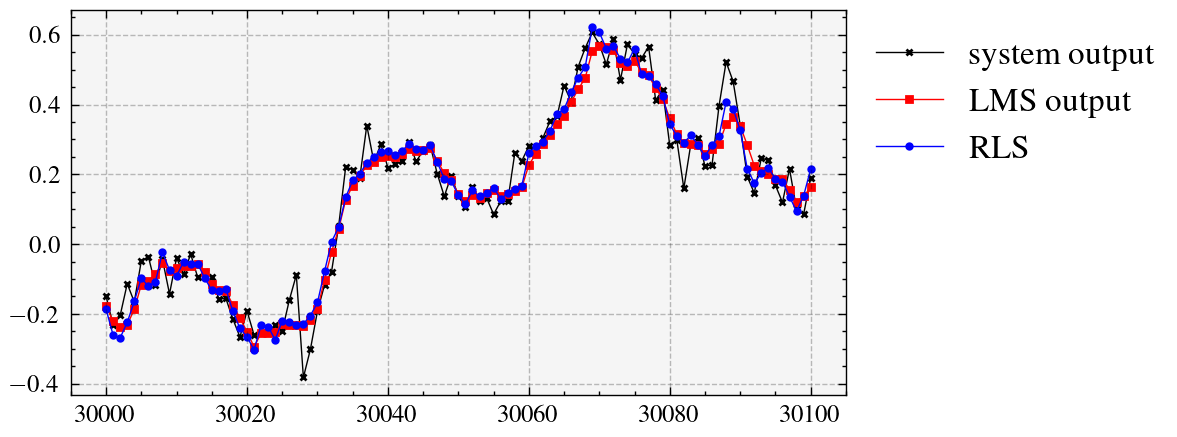

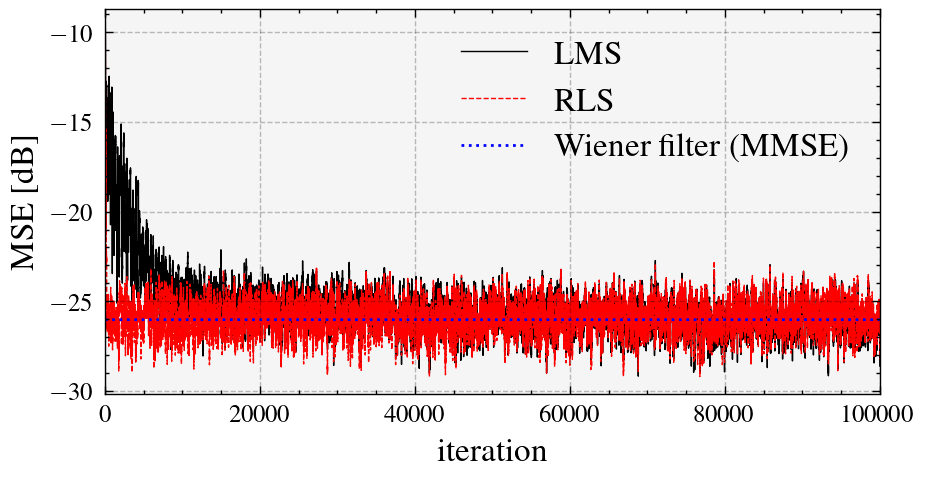

In [13]:
start = 30000
ind = np.arange(start,start+101)

plt.figure()
plt.plot(ind,y[ind],'-xk', label='system output')
plt.plot(ind,out_lms[ind],'-sr', label='LMS output')
plt.plot(ind,out_rls[ind],'-ob', label='RLS')
plt.legend(bbox_to_anchor=(1, 1));
plt.grid()

average_window_len = 50
mse_lms_dB = 10*np.log10(np.convolve(squaredError_lms,np.ones(average_window_len)/average_window_len, 'same'))
mse_rls_dB = 10*np.log10(np.convolve(squaredError_rls,np.ones(average_window_len)/average_window_len, 'same'))

plt.figure()
plt.plot(mse_lms_dB, label='LMS')
plt.plot(mse_rls_dB, label='RLS')
plt.plot(10*np.log10(mmse_sys_id)*np.ones(len(mse_lms_dB)), linewidth=1, label=' Wiener filter (MMSE)')
plt.xlim(0,len(mse_lms_dB))
plt.xlabel('iteration')
plt.ylabel('$\\mathrm{MSE}$ [dB]')
plt.legend()
plt.grid();

### Example of aplication: channel equalization

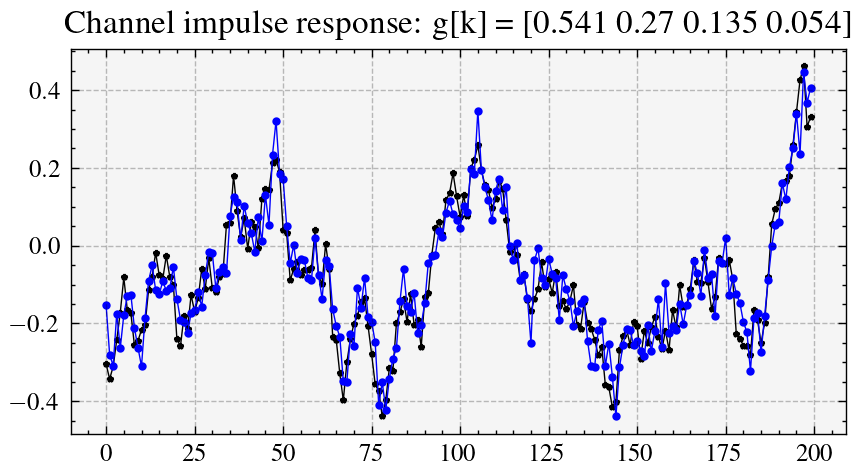

In [14]:
nsamples = 100000
σ2 = 0.0025 # noise variance

# Define input signal to the system
# x = 2*np.random.randint(0, 2, nsamples)-1
x = np.convolve(np.random.normal(0, 0.8, nsamples), np.ones(16)/16,'same')
#x = np.random.normal(0, 1, nsamples)

# Define impulse response of the system
g = np.array([1, 0.5, 0.25, 0.1])
g = g/np.sum(g)

# Convolve input signal with system's impulse response
y = np.convolve(x, g,'same')
y = np.roll(y, 1) # remove input-output delay

# Generate noise and add noise to the systens output
n = np.random.normal(0, np.sqrt(σ2), nsamples)
y += n

plt.plot(x[0:200],'-*k', label='system input')
plt.plot(y[0:200],'-ob', label='system output');
plt.title(f'Channel impulse response: g[k] = {g.round(3)}');

plt.grid()

In [15]:
# Estimate correlation matrix R = E[y*y.T]
R = estimate_correlation_matrix(y, 4)

symdisp('\\boldsymbol{R}_{yy} = ', sp.Matrix(R), numDig=3)

# Calculate eigenvalues and eigenvectors associated to R
eigenvalues, eigenvectors = np.linalg.eig(R)

Λ = sp.Matrix(np.diag(eigenvalues))
Q = sp.Matrix(eigenvectors)

print('Matrix of eigenvalues of R:')
symdisp('\\boldsymbol{Λ} = ', Λ, numDig=3)
# symdisp('\\boldsymbol{Q} = ', Q, numDig=3)
# symdisp('\\boldsymbol{R} = \\boldsymbol{Q}\\boldsymbol{Λ}\\boldsymbol{Q}^T = ', Q*Λ*Q.T, numDig=3)

<IPython.core.display.Math object>

Matrix of eigenvalues of R:


<IPython.core.display.Math object>

In [16]:
# Estimate cross correlation matrix R = E[x*y]
p = estimate_cross_correlation(y, x, 4)

h_opt = np.linalg.inv(R)@p
mmse_ch_eq = np.mean(x**2) - (h_opt.T)@p

print('Impulse response of the channel:')
symdisp('\\boldsymbol{g} = ', sp.Matrix(g), numDig=3)
print('Estimated optimal channel equalizer filter coefficients (Wiener filter):')
symdisp('\\boldsymbol{h}_{opt} =  \\boldsymbol{R}_{yy}^{-1}\\boldsymbol{p}_{xy} =', sp.Matrix(h_opt), numDig=3)
symdisp('\\mathrm{MMSE} = \\mathbb{E}[x^2] - \\boldsymbol{h}_{opt}^{T}\\boldsymbol{p}_{xy} =', sp.Matrix([mmse_ch_eq])[0], numDig=3)

Impulse response of the channel:


<IPython.core.display.Math object>

Estimated optimal channel equalizer filter coefficients (Wiener filter):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

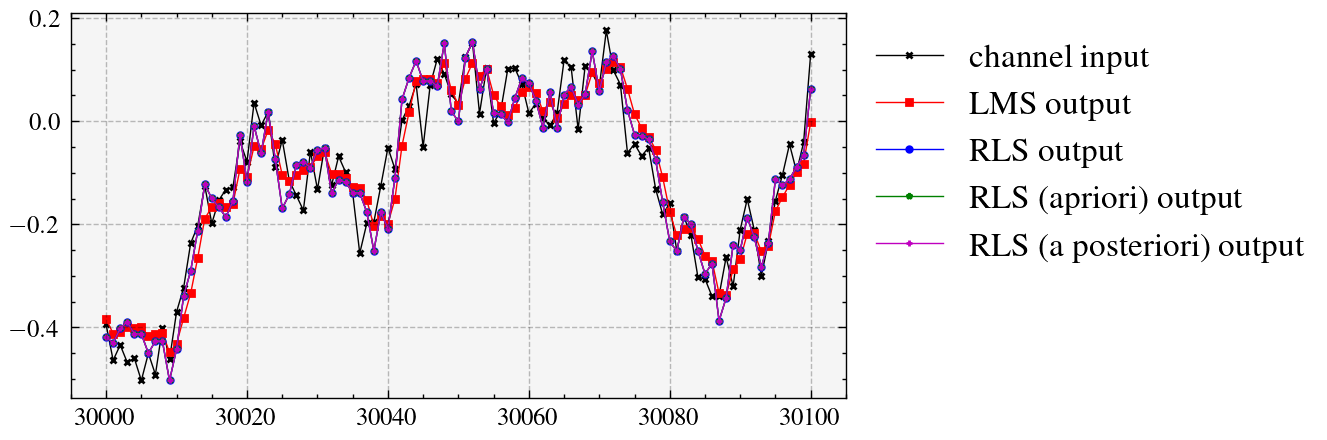

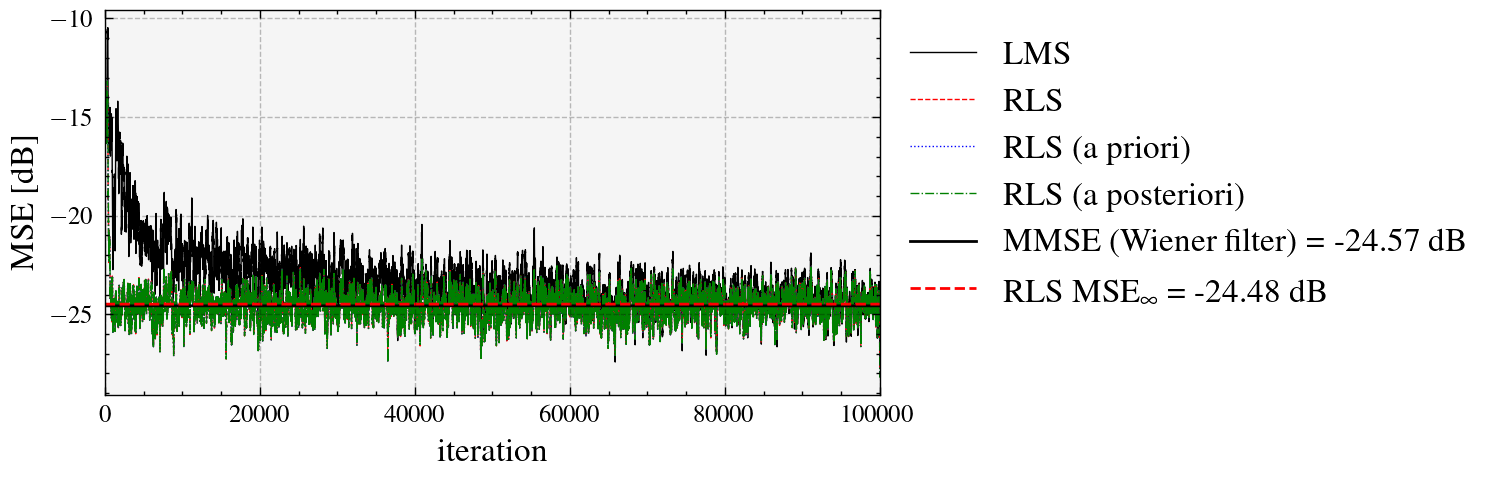

In [35]:
μ = 1e-3
λ = 0.99
Ntaps = 4

# Run LMS and LMS-Newton
out_lms, h, squaredError_lms, H = lms(y, x, Ntaps, μ)
out_rls, h, squaredError_rls, H = rls(y, x, Ntaps, λ)
out_rls_apriori, h, squaredError_rls_apriori, H = rls_apriori(y, x, Ntaps, λ)
out_rls_aposteriori, h, squaredError_rls_aposteriori, H = rls_aposteriori(y, x, Ntaps, λ)

start = 30000
ind = np.arange(start,start+101)

Jmmse_rls = 10*np.log10((1 + Ntaps *(1 - λ)/(1 + λ) ) * mmse_ch_eq)

# Compare results:
plt.figure()
plt.plot(ind, x[ind],'-xk', label='channel input')
plt.plot(ind,out_lms[ind],'-sr', label='LMS output')
plt.plot(ind,out_rls[ind],'-ob', label='RLS output')
plt.plot(ind,out_rls_apriori[ind],'-g*', label='RLS (apriori) output')
plt.plot(ind,out_rls_aposteriori[ind],'-m+', label='RLS (a posteriori) output')
plt.legend(bbox_to_anchor=(1, 1));
plt.grid()

average_window_len = 100
mse_lms_dB = 10*np.log10(np.convolve(squaredError_lms,np.ones(average_window_len)/average_window_len, 'same'))
mse_rls_dB = 10*np.log10(np.convolve(squaredError_rls,np.ones(average_window_len)/average_window_len, 'same'))
mse_rls_apriori_dB = 10*np.log10(np.convolve(squaredError_rls_apriori,np.ones(average_window_len)/average_window_len, 'same'))
mse_rls_aposteriori_dB = 10*np.log10(np.convolve(squaredError_rls_aposteriori,np.ones(average_window_len)/average_window_len, 'same'))

plt.figure()
plt.plot(mse_lms_dB, label=' LMS')
plt.plot(mse_rls_dB, label='RLS')
plt.plot(mse_rls_apriori_dB, label='RLS (a priori)')
plt.plot(mse_rls_aposteriori_dB, label='RLS (a posteriori)')
plt.plot(10*np.log10(mmse_ch_eq)*np.ones(len(mse_lms_dB)), linewidth=1, label='MMSE (Wiener filter) = ' + f'{10*np.log10(mmse_ch_eq):.2f} dB')
plt.plot(Jmmse_rls*np.ones(len(mse_lms_dB)), linewidth=1, label=f'RLS MSE$_\\infty$ = {Jmmse_rls:.2f} dB')
plt.xlim(0,len(mse_lms_dB))
plt.xlabel('iteration')
plt.ylabel('$\\mathrm{MSE}$ [dB]')
plt.legend(bbox_to_anchor=(1, 1));
#plt.xlim(0,20000)
plt.grid();

## Time-varying systems

In [101]:
from algorithms import time_varying_filter
from utils import random_square_signal

In [102]:
σ2 = 0.00025 # noise variance
Ntaps = 4
H = np.zeros((len(x), Ntaps))

fh = 100
fs = 500000
timeIdx = np.arange(len(x))*(1/fs)

H[:,0] = 1
H[:,1] = 0.75 + 0.25*np.sin(2*np.pi*fh*timeIdx + np.pi/67)
H[:,2] = 0.25 + 0.125*np.cos(2*np.pi*fh*timeIdx + np.pi/13)
H[:,3] = 0.05 + 0.05*np.sin(2*np.pi*fh*timeIdx + np.pi/77)


# Time-varying system
y = time_varying_filter(x, H)

# Generate noise and add noise to the systens output
n = np.random.normal(0, np.sqrt(σ2), len(y))
y += n

# Parameters to run LMS, NLMS, LMS-Newton and RLS
μ = 5e-3
α = 2*μ 
Ntaps = 4
λ = 0.99

out_lms, h, squaredError_lms, H_lms = lms(x, y, Ntaps, μ)
out_lms_newton, h, squaredError_lms_newton, H_lms_newton = lms_newton(x, y, Ntaps, μ, α)
out_nlms, h, squaredError_nlms, H_nlms = nlms(x, y, Ntaps, μ)
out_rls, h, squaredError_rls, H_rls = rls(x, y, Ntaps, λ)

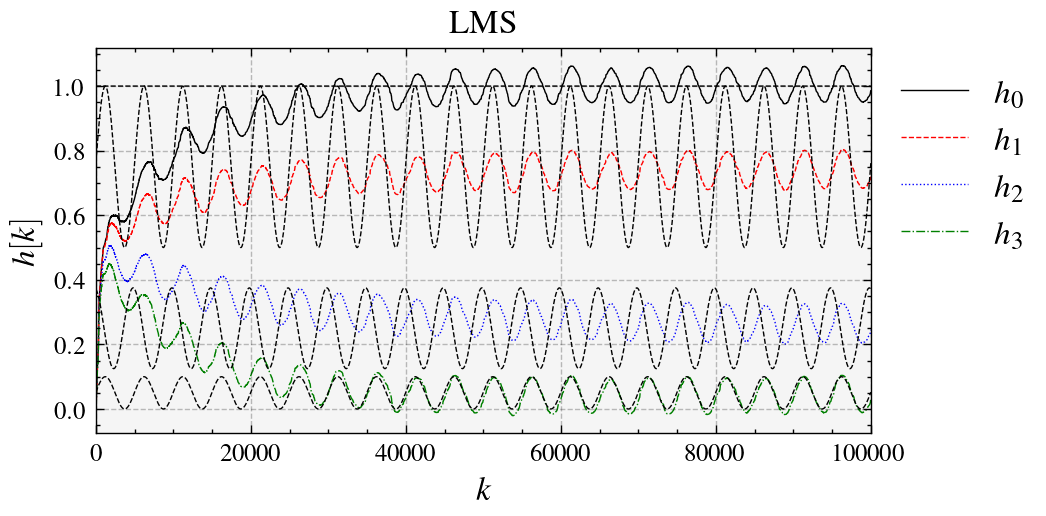

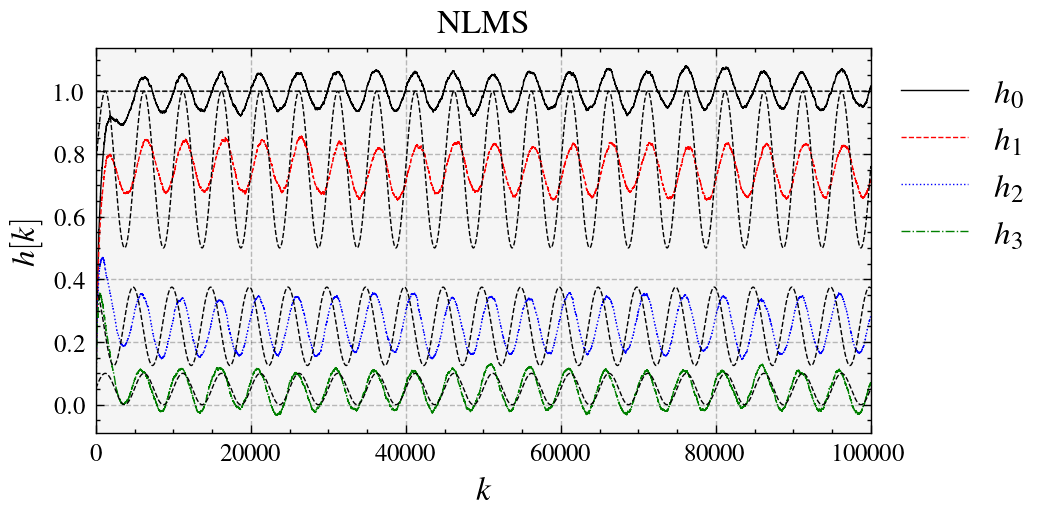

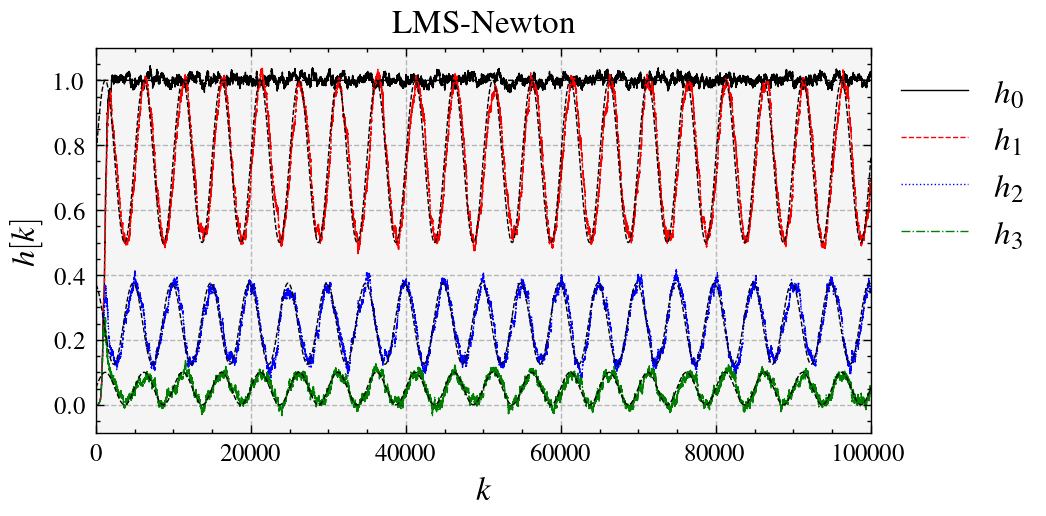

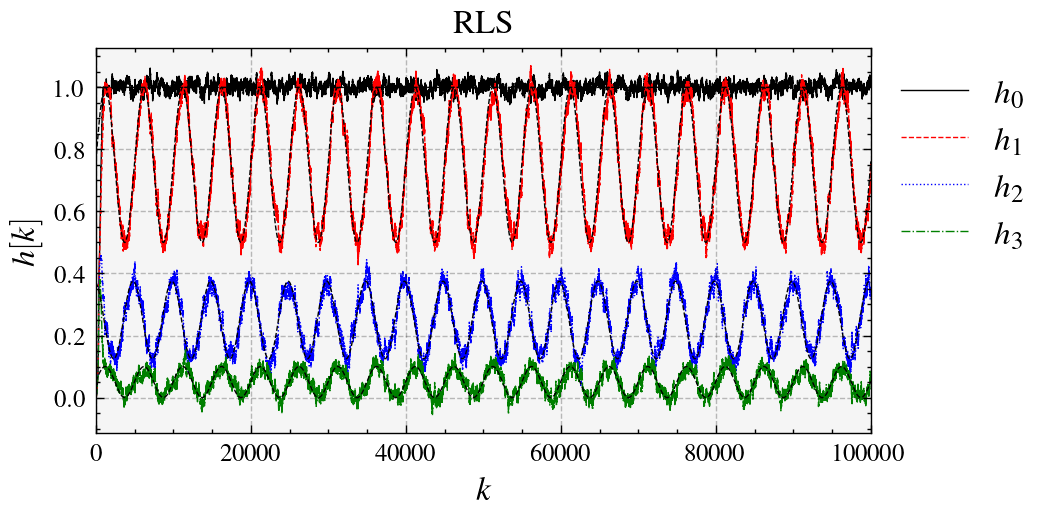

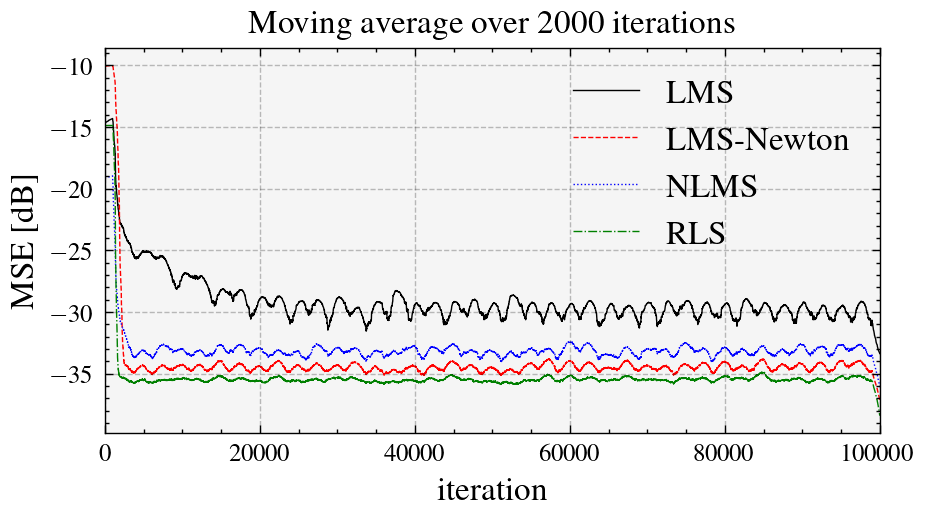

In [103]:
plt.figure()
for k in range(Ntaps):
    plt.plot(H_lms[:,k],label = f'$h_{k}$')
    
for k in range(Ntaps):
    plt.plot(H[:,k],'--k', linewidth=0.5)
    
plt.xlabel('$k$')
plt.ylabel('$\\boldsymbol{h}[k]$')
plt.title('LMS')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();
plt.xlim(0,H.shape[0])

plt.figure()
for k in range(Ntaps):
    plt.plot(H_nlms[:,k],label = f'$h_{k}$')

for k in range(Ntaps):
    plt.plot(H[:,k],'--k', linewidth=0.5)
    
plt.xlabel('$k$')
plt.ylabel('$\\boldsymbol{h}[k]$')
plt.title('NLMS')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();
plt.xlim(0,H.shape[0])

plt.figure()
for k in range(Ntaps):
    plt.plot(H_lms_newton[:,k],label = f'$h_{k}$')

for k in range(Ntaps):
    plt.plot(H[:,k],'--k', linewidth=0.5)
    
plt.xlabel('$k$')
plt.ylabel('$\\boldsymbol{h}[k]$')
plt.title('LMS-Newton')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();
plt.xlim(0,H.shape[0])

plt.figure()
for k in range(Ntaps):
    plt.plot(H_rls[:,k],label = f'$h_{k}$')

for k in range(Ntaps):
    plt.plot(H[:,k],'--k', linewidth=0.5)
    
plt.xlabel('$k$')
plt.ylabel('$\\boldsymbol{h}[k]$')
plt.title('RLS')
plt.legend()
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();
plt.xlim(0,H.shape[0])


average_window_len = 2000
mse_lms_dB = 10*np.log10(np.convolve(squaredError_lms,np.ones(average_window_len)/average_window_len, 'same'))
mse_lms_newton_dB = 10*np.log10(np.convolve(squaredError_lms_newton,np.ones(average_window_len)/average_window_len, 'same'))
mse_nlms_dB = 10*np.log10(np.convolve(squaredError_nlms,np.ones(average_window_len)/average_window_len, 'same'))
mse_rls_dB = 10*np.log10(np.convolve(squaredError_rls,np.ones(average_window_len)/average_window_len, 'same'))

plt.figure()
plt.title(f'Moving average over {average_window_len} iterations')
plt.plot(mse_lms_dB, label=' LMS')
plt.plot(mse_lms_newton_dB, label='LMS-Newton')
plt.plot(mse_nlms_dB, label='NLMS')
plt.plot(mse_rls_dB, label='RLS')
plt.xlim(0,len(mse_lms_dB))
plt.xlabel('iteration')
plt.ylabel('$\\mathrm{MSE}$ [dB]')
plt.legend(bbox_to_anchor=(1, 1));
#plt.xlim(0,20000)
plt.grid();